# <b> Entendiendo Burgers Equation </b>

## ¿Que representa?
# $ \frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \frac{\partial^2 u }{ \partial x^2} $

Donde 
$\frac{\partial u}{\partial t} $ : Cambio con respecto al tiempo t

$ u \frac{\partial u}{\partial x}$ : la propia solucion se transporta asi misma; es decir es no lineal, $\frac{\partial u}{\partial x}$ Es la pendiente o el gradiente de velocidad en el espacio. Te dice si el fluido adelante va más rápido o más lento. 

$\frac{\partial^2 u }{ \partial x^2}$ Difusion 


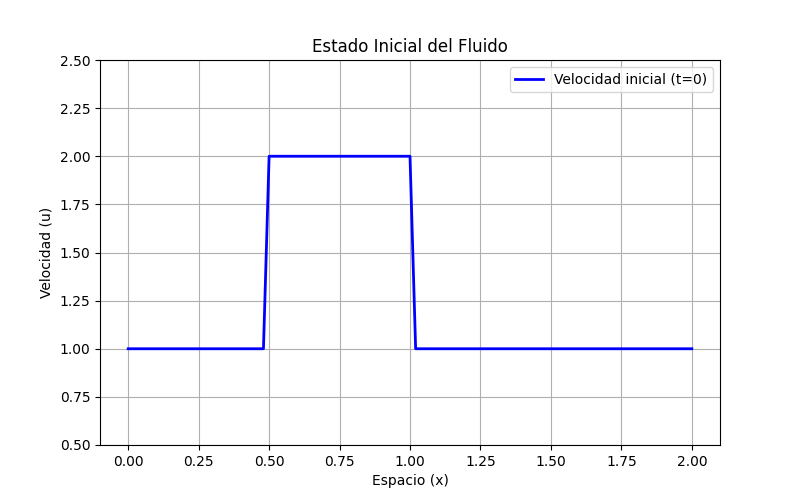

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros del espacio El canal del fluido
nx = 101          # Número de puntos en el espacio
dx = 2.0 / (nx-1) # Distancia entre cada punto
x = np.linspace(0, 2, nx) # El espacio va de 0 a 2 metros

# 2. Condiciones Iniciales: Creamos una "ola cuadrada"
# Todo el fluido va a velocidad 1, pero entre x=0.5 y x=1.0 va a velocidad 2
u = np.ones(nx)      
u[int(0.5 / dx):int(1.0 / dx + 1)] = 2  

# 3. Graficar el estado inicial
plt.figure(figsize=(8, 5))
plt.plot(x, u, color='blue', linewidth=2, label='Velocidad inicial (t=0)')
plt.ylim(0.5, 2.5)
plt.xlabel('Espacio (x)')
plt.ylabel('Velocidad (u)')
plt.title('Estado Inicial del Fluido')
plt.grid(True)
plt.legend()
plt.show()


C:\Users\avazq\AppData\Local\Temp\ipykernel_12364\937534670.py:14: RuntimeWarning: overflow encountered in scalar multiply
  u[i] = un[i] - un[i] * (dt / dx) * (un[i] - un[i-1])
C:\Users\avazq\AppData\Local\Temp\ipykernel_12364\937534670.py:14: RuntimeWarning: invalid value encountered in scalar subtract
  u[i] = un[i] - un[i] * (dt / dx) * (un[i] - un[i-1])


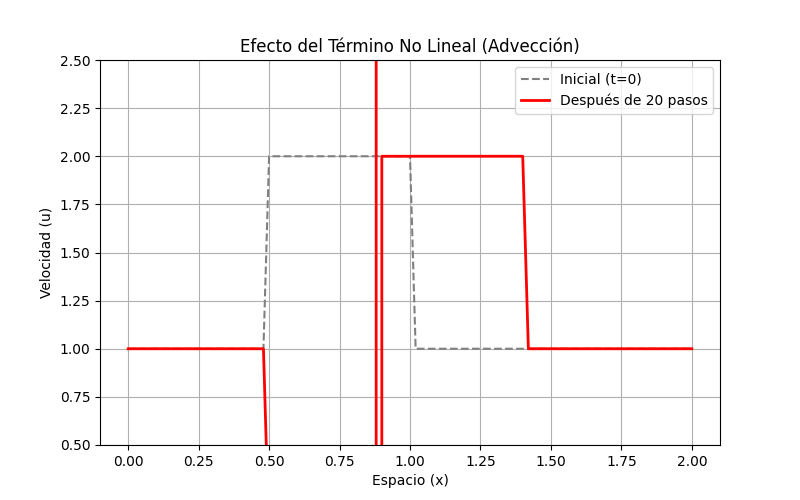

In [2]:
# 4. Parámetros del tiempo
nt = 20           # Número de pasos en el tiempo que queremos simular
dt = 0.02         # Qué tan pequeño es cada paso de tiempo

# Guardamos una copia de la condición inicial para comparar
u_inicial = u.copy()

# 5. Bucle en el tiempo (Simulación)
for n in range(nt):
    un = u.copy() # Copia del estado actual antes de actualizar
    
    # Recorremos cada punto del espacio (nos saltamos el primero x=0 por condición de frontera)
    for i in range(1, nx):
        u[i] = un[i] - un[i] * (dt / dx) * (un[i] - un[i-1])

# 6. Graficar el resultado de la deformación
plt.figure(figsize=(8, 5))
plt.plot(x, u_inicial, '--', color='gray', label='Inicial (t=0)')
plt.plot(x, u, color='red', linewidth=2, label=f'Después de {nt} pasos')
plt.ylim(0.5, 2.5)
plt.xlabel('Espacio (x)')
plt.ylabel('Velocidad (u)')
plt.title('Efecto del Término No Lineal (Advección)')
plt.grid(True)
plt.legend()
plt.show()


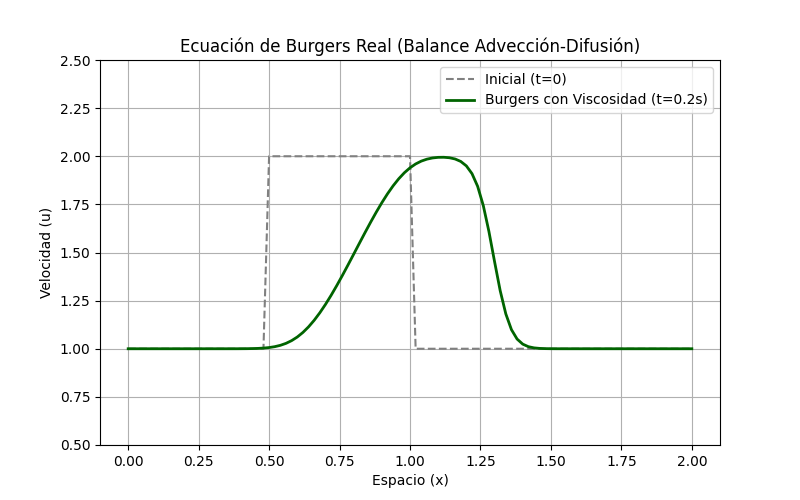

In [3]:
# Reiniciamos las condiciones iniciales para limpiar el error anterior
u = np.ones(nx)      
u[int(0.5 / dx):int(1.0 / dx + 1)] = 2  
u_inicial = u.copy()

# Parámetros físicos y temporales
nu = 0.01   # Constante de viscosidad (difusión)
nt = 40     # Avanzamos un poco más en el tiempo para ver el efecto claro
dt = 0.005  # Reducimos dt para garantizar estabilidad numérica

# Bucle con la Ecuación de Burgers COMPLETA
for n in range(nt):
    un = u.copy()
    for i in range(1, nx - 1): # Dejamos extremos fijos para evitar desbordamiento
        # Término no lineal + Término de difusión
        u[i] = (un[i] 
                - un[i] * (dt / dx) * (un[i] - un[i-1]) 
                + nu * (dt / dx**2) * (un[i+1] - 2*un[i] + un[i-1]))

# Graficar el resultado real y limpio
plt.figure(figsize=(8, 5))
plt.plot(x, u_inicial, '--', color='gray', label='Inicial (t=0)')
plt.plot(x, u, color='darkgreen', linewidth=2, label=f'Burgers con Viscosidad (t={nt*dt}s)')
plt.ylim(0.5, 2.5)
plt.xlabel('Espacio (x)')
plt.ylabel('Velocidad (u)')
plt.title('Ecuación de Burgers Real (Balance Advección-Difusión)')
plt.grid(True)
plt.legend()
plt.show()


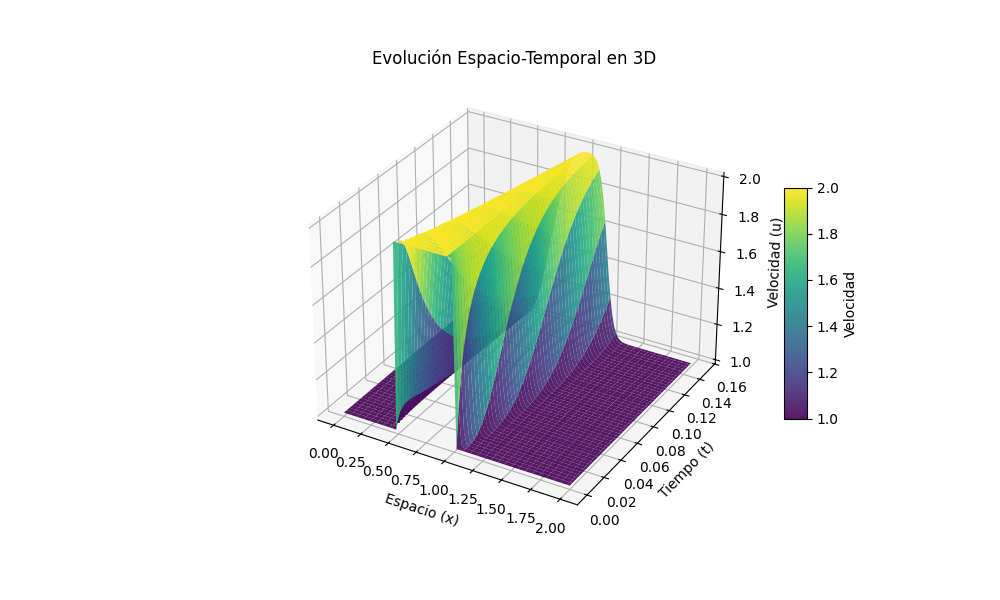

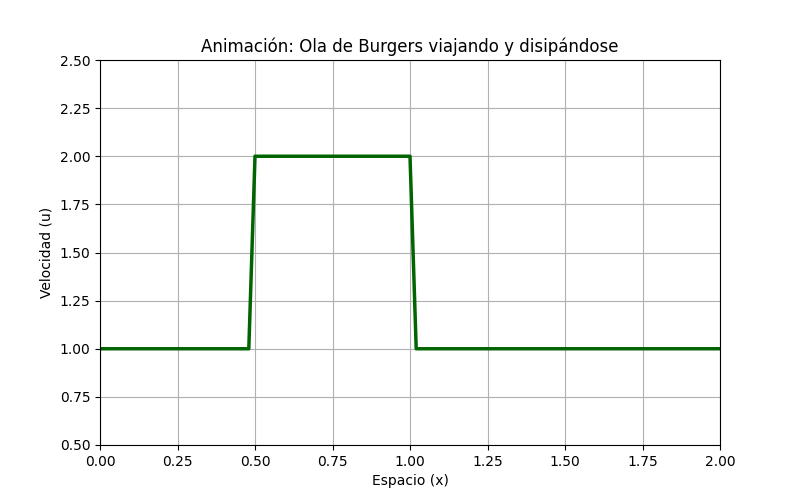

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

nx = 101
dx = 2.0 / (nx - 1)
x = np.linspace(0, 2, nx)

nt = 150        # Más pasos de tiempo para ver todo el viaje
dt = 0.001     # Paso temporal ajustado para estabilidad
nu = 0.01      # Viscosidad

# Matriz para guardar la velocidad en CADA instante de tiempo (para el gráfico 3D)
# Filas = tiempo, Columnas = espacio
u_historia = np.zeros((nt, nx))

# Condición inicial (ola cuadrada)
u = np.ones(nx)
u[int(0.5 / dx):int(1.0 / dx + 1)] = 2
u_historia[0, :] = u.copy()

# Cálculo de la historia temporal
for n in range(1, nt):
    un = u.copy()
    for i in range(1, nx - 1):
        u[i] = (un[i] 
                - un[i] * (dt / dx) * (un[i] - un[i-1]) 
                + nu * (dt / dx**2) * (un[i+1] - 2*un[i] + un[i-1]))
    u_historia[n, :] = u.copy()

#  GRÁFICA 3D SUPERFICIE DEL ESPACIOTIEMPO
fig_3d = plt.figure(figsize=(10, 6))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# Creamos mallas para el Espacio (X) y el Tiempo (T)
T, X = np.meshgrid(np.linspace(0, nt*dt, nt), x, indexing='ij')

# Graficamos la superficie u(x, t)
surf = ax_3d.plot_surface(X, T, u_historia, cmap='viridis', edgecolor='none', alpha=0.9)
ax_3d.set_xlabel('Espacio (x)')
ax_3d.set_ylabel('Tiempo (t)')
ax_3d.set_zlabel('Velocidad (u)')
ax_3d.set_title('Evolución Espacio-Temporal en 3D')
fig_3d.colorbar(surf, ax=ax_3d, shrink=0.5, aspect=10, label='Velocidad')
plt.show()

# ANIMACIÓN 2D EN TIEMPO REAL
fig_anim, ax_anim = plt.subplots(figsize=(8, 5))
ax_anim.set_xlim(0, 2)
ax_anim.set_ylim(0.5, 2.5)
ax_anim.set_xlabel('Espacio (x)')
ax_anim.set_ylabel('Velocidad (u)')
ax_anim.grid(True)

linea, = ax_anim.plot(x, u_historia[0, :], color='darkgreen', linewidth=2.5)
texto_tiempo = ax_anim.text(0.05, 2.3, '', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

def actualizar(paso):
    linea.set_ydata(u_historia[paso, :])
    texto_tiempo.set_text(f'Tiempo = {paso * dt:.3f} s')
    return linea, texto_tiempo

# Crear la animación (corre a 30 cuadros por segundo aproximadamente)
ani = FuncAnimation(fig_anim, actualizar, frames=nt, interval=40, blit=True)
plt.title('Animación: Ola de Burgers viajando y disipándose')
plt.show()
